Libraries for File Processing


In [ ]:
import os
import zipfile
import pandas as pd
import random


Libraries for Data Manipulation and Image Analysis

In [27]:
import imageio.v2 as imageio
import pandas as pd
import numpy as np 

import matplotlib.pylab as plt
%matplotlib inline

from scipy.stats import norm
from scipy import ndimage as ndi

## Step 1: Loading Data
    

For computational purposes, only 15 patients will be selected

In [4]:
metadata = pd.read_csv('train_images\\.csv')
meta_patients = set(metadata['Patient'])

In [26]:
def extract_n_patients(zip_path, dest_dir, n, meta_patients):
    with zipfile.ZipFile(zip_path) as zf:
        names = zf.namelist()
        patients = sorted(set(name.split('/')[0] for name in names if name.split('/')[0] in meta_patients))[:n]
        for name in names:
            if name.split('/')[0] in patients:
                zf.extract(name, dest_dir)
    return patients

number_of_patients = 15
chosen_patients = extract_n_patients('train.zip', 'train_images', n=number_of_patients, meta_patients=meta_patients)


In [6]:
len(chosen_patients)

15

In [ ]:

patients_metadata = pd.read_csv('train_images\\.csv')
patients_metadata = patients_metadata[patients_metadata['Patient'].isin(chosen_patients)]

patients_metadata['Patient'].nunique() 


15

In [ ]:


folder = 'train_images/ID00007637202177411956430'   #
sample_vol = imageio.volread(folder, 'DICOM')

print(type(sample_vol))
print(sample_vol.shape)

Reading DICOM (examining files): 1/30 files (3.3%30/30 files (100.0%)
  Found 1 correct series.
Reading DICOM (loading data): 30/30  (100.0%)
<class 'imageio.core.util.Array'>
(30, 512, 512)


In [9]:
def build_patient_map(image_dir, patient_ids):
    """Load each patient's DICOM volume + meta into a dict keyed by patient ID."""
    patient_data = {}

    for pid in patient_ids:
        folder = os.path.join(image_dir, pid)     
        try:
            vol = imageio.volread(folder, 'DICOM')
            patient_data[pid] = vol
        except Exception as e:
            print(f"Failed to load {pid}: {e}")    
    return patient_data

patients_data = build_patient_map('train_images', patients_metadata['Patient'].unique())


Reading DICOM (examining files): 1/30 files (3.3%30/30 files (100.0%)
  Found 1 correct series.
Reading DICOM (loading data): 30/30  (100.0%)
Reading DICOM (examining files): 1/394 files (0.3394/394 files (100.0%)
  Found 1 correct series.
Reading DICOM (loading data): 51/394  (12.9%100/394  (25.4154/394  (39.1205/394  (52.0259/394  (65.7314/394  (79.7371/394  (94.2394/394  (100.0%)
Reading DICOM (examining files): 1/106 files (0.9106/106 files (100.0%)
  Found 1 correct series.
Reading DICOM (loading data): 106/106  (100.0%)
Reading DICOM (examining files): 1/31 files (3.2  The dicom reader can only read files with uncompressed image data - not '1.2.840.10008.1.2.4.70' (JPEG). You can try using dcmtk or gdcm to convert the image.
Reading DICOM (examining files): 1/31 files (3.2  The dicom reader can only read files with uncompressed image data - not '1.2.840.10008.1.2.4.70' (JPEG). You can try using dcmtk or gdcm to convert the image.
Reading DICOM (examining files): 1/31 files (3.2  

(29, 512, 512)


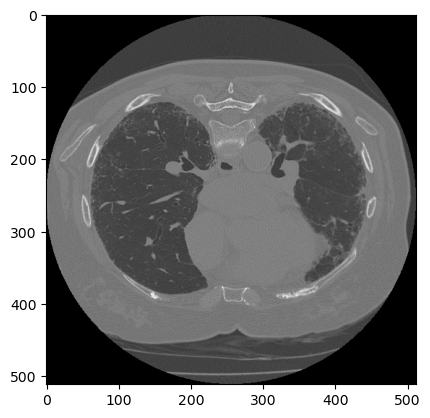

In [10]:
# Pick a random patient and show a middle slice to confirm the volume looks like a chest CT
random.seed(0)
random_pid = random.choice(list(patients_data.keys()))
random_vol = patients_data[random_pid]  
print(random_vol.shape)

mid = random_vol.shape[0] // 2
plt.imshow(random_vol[mid, :, :], cmap='gray')       
plt.show()


Step 2: 

Quality Control

In [11]:
patients_metadata.describe()

,Weeks,FVC,Percent,Age
count,133.000000,133.000000,133.000000,133.000000
mean,30.270677,2872.195489,80.565737,67.902256
std,22.190678,802.571912,16.723268,7.300752
min,-4.000000,1304.000000,50.327126,56.000000
25%,12.000000,2250.000000,67.702732,63.000000
50%,26.000000,2887.000000,80.661841,69.000000
75%,45.000000,3373.000000,90.076661,72.000000
max,98.000000,5045.000000,119.629138,83.000000


In [12]:
patients_metadata.isna().sum()


Patient          0
Weeks            0
FVC              0
Percent          0
Age              0
Sex              0
SmokingStatus    0
dtype: int64

In [13]:
patients_metadata.info()

<class 'pandas.core.frame.DataFrame'>
Index: 133 entries, 0 to 132
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Patient        133 non-null    object 
 1   Weeks          133 non-null    int64  
 2   FVC            133 non-null    int64  
 3   Percent        133 non-null    float64
 4   Age            133 non-null    int64  
 5   Sex            133 non-null    object 
 6   SmokingStatus  133 non-null    object 
dtypes: float64(1), int64(3), object(3)
memory usage: 8.3+ KB


In [14]:
patients_metadata['Patient'].value_counts()

Patient
ID00007637202177411956430    9
ID00009637202177434476278    9
ID00010637202177584971671    9
ID00011637202177653955184    9
ID00012637202177665765362    9
ID00014637202177757139317    9
ID00019637202178323708467    9
ID00020637202178344345685    9
ID00023637202179104603099    9
ID00025637202179541264076    9
ID00026637202179561894768    9
ID00027637202179689871102    9
ID00032637202181710233084    9
ID00015637202177877247924    8
ID00030637202181211009029    8
Name: count, dtype: int64

In [15]:
for pid, vol in patients_data.items():
    n_nan = np.isnan(vol).sum()
    print(f"{pid}:, shape = {vol.shape} NaN pixels={n_nan}")

ID00007637202177411956430:, shape = (30, 512, 512) NaN pixels=0
ID00009637202177434476278:, shape = (394, 768, 768) NaN pixels=0


C:\Users\Dhana\AppData\Local\Temp\ipykernel_15596\1616012460.py:2: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  n_nan = np.isnan(vol).sum()


ID00010637202177584971671:, shape = (106, 512, 512) NaN pixels=0
ID00012637202177665765362:, shape = (49, 512, 512) NaN pixels=0
ID00014637202177757139317:, shape = (31, 843, 888) NaN pixels=0
ID00015637202177877247924:, shape = (280, 768, 768) NaN pixels=0
ID00019637202178323708467:, shape = (29, 512, 512) NaN pixels=0
ID00020637202178344345685:, shape = (493, 512, 512) NaN pixels=0
ID00023637202179104603099:, shape = (27, 512, 512) NaN pixels=0
ID00025637202179541264076:, shape = (24, 768, 768) NaN pixels=0
ID00027637202179689871102:, shape = (358, 768, 768) NaN pixels=0
ID00030637202181211009029:, shape = (433, 512, 512) NaN pixels=0
ID00032637202181710233084:, shape = (205, 512, 512) NaN pixels=0




Checked all 15 patients — no missing metadata, no NaN pixels, all passed. 

Step 3: 

Highlighting lung tissue in image 

Sources:
- Lung tissue HU values: https://biologyinsights.com/the-hounsfield-unit-chart-what-the-numbers-mean/

Lung tissue is typically represented with HU values between -700 and -600 HU. Since 
most of the CT scan is air (around -1000 HU) and the surrounding body tissue and bone 
sit much higher (muscle around +45 HU, bone above +400 HU), the lungs fall into a low, 
well-separated band. We use this gap to isolate the lungs: by thresholding the scan to 
keep only the low-HU regions, we separate lung tissue from the denser tissue and bone 
around it.

Checking the DICOM rescale tags per patient showed this dataset's raw pixel values were 
already stored on the HU scale, so no rescale was re-applied (applying it a second time 
double-shifted the values and broke the threshold).

Segmentation steps:
1. Gaussian filter (scipy.ndimage) to reduce speckle noise before thresholding.
2. Threshold band of -950 to -300 HU to capture the full lung cavity.
3. Label connected regions with ndi.label, then keep only the two largest components — 
   the left and right lungs — which drops the scanner table and body-wall speckle that 
   share the lungs' HU range but form separate blobs.
4. Fill enclosed holes (ndi.binary_fill_holes) so vessels, airways, and dense fibrotic 
   tissue inside the lungs are counted as lung rather than left as gaps.


Segmentation Reference: https://medium.com/@dinuScripnic/segmentation-of-ct-scan-with-python-21e298411443


In [16]:
patients_hu = {}
for pid, vol in patients_data.items():
    patients_hu[pid] = np.asarray(vol)


In [17]:
pid = list(patients_hu.keys())[0]
hu = patients_hu[pid]
print(f"Size of HU: {hu.shape} HU range: {hu.min()}, {hu.max()}")

Size of HU: (30, 512, 512) HU range: -3024, 2330


In [ ]:
from skimage.segmentation import clear_border

def get_lung_mask(hu):
    hu_smooth = ndi.gaussian_filter(hu, sigma=1)
    mask = (hu_smooth > -950) & (hu_smooth < -300)

    cleared = np.zeros_like(mask)
    for i in range(mask.shape[0]):
        cleared[i] = clear_border(mask[i])

    labels, n = ndi.label(cleared)
    sizes = ndi.sum(cleared, labels, range(1, n + 1))
    lungs = np.isin(labels, np.where(sizes > 10000)[0] + 1)

    lungs_holes_filled = ndi.binary_fill_holes(lungs)
    return lungs_holes_filled

patients_masks = {}
for pid, hu in patients_hu.items():
    patients_masks[pid] = get_lung_mask(hu)
    print(f"{pid}: {patients_masks[pid].sum()} lung voxels")


ID00007637202177411956430: 2014171 lung voxels
ID00009637202177434476278: 29827654 lung voxels
ID00010637202177584971671: 2040222 lung voxels
ID00012637202177665765362: 1667840 lung voxels
ID00014637202177757139317: 1462858 lung voxels
ID00015637202177877247924: 19122603 lung voxels
ID00019637202178323708467: 850535 lung voxels
ID00020637202178344345685: 14162240 lung voxels
ID00023637202179104603099: 835081 lung voxels
ID00025637202179541264076: 2753728 lung voxels
ID00027637202179689871102: 20108234 lung voxels
ID00030637202181211009029: 18756552 lung voxels
ID00032637202181710233084: 6844572 lung voxels


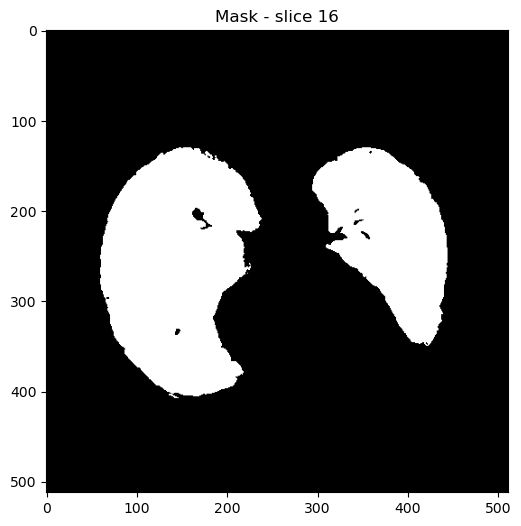

In [19]:
mask = patients_masks[random_pid]          
best = int(mask.sum(axis=(1, 2)).argmax())  
plt.figure(figsize=(6, 6))
plt.imshow(mask[best], cmap='gray')         
plt.title(f"Mask - slice {best}")
plt.show()

Step 4

Lung volume = number of lung voxels × the real-world size of one voxel. Voxel size 
comes from the DICOM metadata (vol.meta['sampling'] = slice thickness × pixel spacing, 
in mm). Multiplying by the voxel count and dividing by 1000 gives volume in cm³. 
Computed per patient, so scans of different resolutions are all measured consistently.

In [20]:
def lung_volume_cm3(lungs, vol):
    """Lung volume in cm³ from a lung mask + its DICOM volume (for spacing)."""
    dz, dy, dx = vol.meta['sampling']      
    voxel_mm3 = dz * dy * dx                 
    return (lungs.sum() * voxel_mm3) / 1000  

In [21]:
lung_vol = {}
for pid, lungs in patients_masks.items():
    lung_vol[pid] = lung_volume_cm3(lungs, patients_data[pid])
    print(f"{pid}: {lung_vol[pid]:.0f} cm³")

ID00007637202177411956430: 8571 cm³
ID00009637202177434476278: 5659 cm³
ID00010637202177584971671: 2620 cm³
ID00012637202177665765362: 4560 cm³
ID00014637202177757139317: 9335 cm³
ID00015637202177877247924: 4178 cm³
ID00019637202178323708467: 3386 cm³
ID00020637202178344345685: 2766 cm³
ID00023637202179104603099: 2679 cm³
ID00025637202179541264076: 5461 cm³
ID00027637202179689871102: 7027 cm³
ID00030637202181211009029: 9177 cm³
ID00032637202181710233084: 6119 cm³


Step 5 

Plotting to see how lung capacity affects FVC and calculating the correlation value


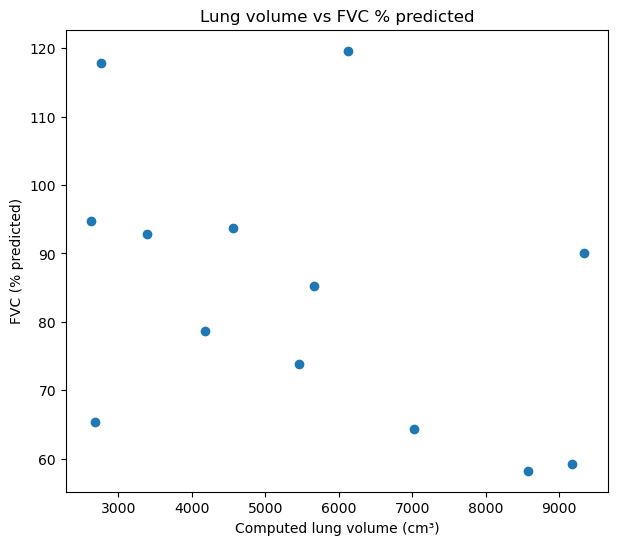

correlation: -0.42


In [23]:

pct = patients_metadata.groupby('Patient')['Percent'].first()

pids = list(lung_vol.keys())
x = [lung_vol[pid] for pid in pids]
y = [pct[pid] for pid in pids]

plt.figure(figsize=(7, 6))
plt.scatter(x, y)
plt.xlabel('Computed lung volume (cm³)')
plt.ylabel('FVC (% predicted)')
plt.title('Lung volume vs FVC % predicted')
plt.show()

r = np.corrcoef(x, y)[0, 1]
print(f"correlation: {r:.2f}")

Step 6 

Comparing Original and Modified Images

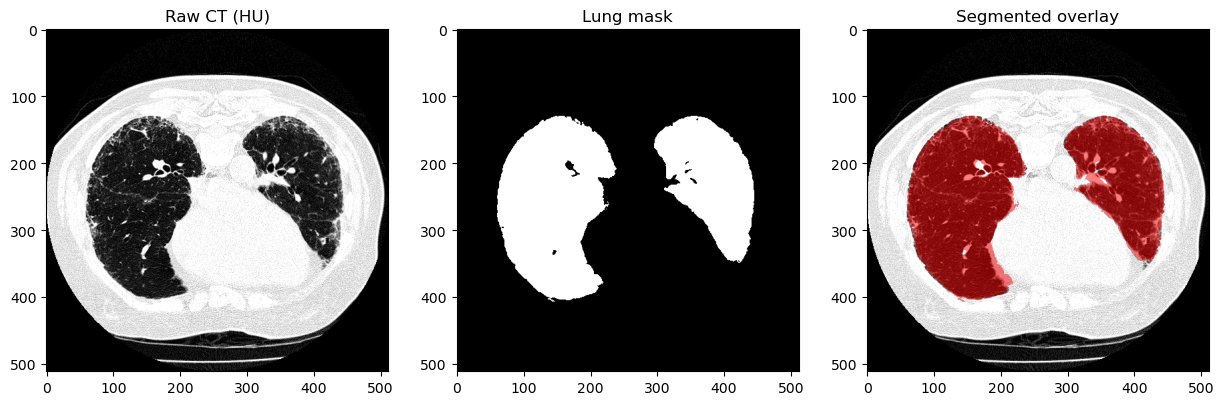

In [ ]:
pid = random_pid
hu = patients_hu[pid]
mask = patients_masks[pid]

best = int(mask.sum(axis=(1, 2)).argmax())

fig, ax = plt.subplots(1, 3, figsize=(15, 5))

ax[0].imshow(hu[best], cmap='gray', vmin=-1000, vmax=0)
ax[0].set_title('Raw CT (HU)')

ax[1].imshow(mask[best], cmap='gray')
ax[1].set_title('Lung mask')

ax[2].imshow(hu[best], cmap='gray', vmin=-1000, vmax=0)
ax[2].imshow(np.ma.masked_where(~mask[best], mask[best]), cmap='autumn', alpha=0.5)
ax[2].set_title('Segmented overlay')

plt.show()

## Final Thoughts

This project built a full pipeline that loads CT scans, isolates the lungs by 
thresholding on Hounsfield Units, cleans up the mask, and computes each patient's lung 
volume and finally compares it against FVC as a sanity check.

The pipeline ran on 15 patients rather than the full dataset purely for computational 
reasons: loading and segmenting full DICOM volumes is memory and time-heavy. The pipeline can be easily scaled for more patients.

That small sample is also the main caveat for the results. With only 13 usable patients, 
the volume–FVC correlation is weak and unstable. A couple of outliers shift it 
significantly, and it isn't statistically strong. Running the same pipeline on hundreds 
of patients would give a far more reliable picture of whether computed lung volume 
actually tracks lung function. 